In [2]:
!pip install osmnx geopandas rasterio rasterstats shapely contextily mapclassify --quiet

In [3]:
from google.colab import files
uploaded = files.upload()

Saving wards_kolkata.geojson to wards_kolkata.geojson


In [4]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

kmc = gpd.read_file("wards_kolkata.geojson")
kmc = kmc.to_crs(epsg=4326)
boundary_polygon = kmc.geometry.union_all()

G = ox.graph_from_polygon(boundary_polygon, network_type='drive')
G = ox.truncate.largest_component(G, strongly=True)

tags = {'amenity': ['hospital', 'clinic'], 'healthcare': True}
facilities = ox.features_from_polygon(boundary_polygon, tags)
facilities = facilities[facilities.geometry.type.isin(['Point', 'Polygon'])].copy()
facilities['geometry'] = facilities.geometry.centroid

print(f"Roads: {len(G.nodes)} nodes, {len(G.edges)} edges")
print(f"Facilities found: {len(facilities)}")

fig, ax = ox.plot_graph(G, show=False, close=False)
facilities.plot(ax=ax, color='red', markersize=20)
plt.savefig("sanity_check.png")
plt.show()

InsufficientResponseError: No data elements in server response. Check query location/filters and log.

In [5]:
print(kmc.crs)
print(kmc.geometry.is_valid.value_counts())
print(boundary_polygon.bounds)
print(boundary_polygon.geom_type)
print(boundary_polygon.is_valid)

EPSG:4326
True     140
False      1
Name: count, dtype: int64
(22.4503235, 88.2421429, 22.6325769, 88.4589549)
MultiPolygon
True


In [6]:
from shapely.ops import transform

# Swap x,y coordinates (fixes lat/lon flip)
kmc['geometry'] = kmc['geometry'].apply(lambda geom: transform(lambda x, y: (y, x), geom))

# Also fix the one invalid geometry while we're at it
kmc['geometry'] = kmc['geometry'].buffer(0)

boundary_polygon = kmc.geometry.union_all()

# Re-check
print(boundary_polygon.bounds)
print(boundary_polygon.is_valid)

TypeError: <lambda>.<locals>.<lambda>() takes 2 positional arguments but 3 were given

In [7]:
from shapely.ops import transform

def swap_xy(*args):
    x, y = args[0], args[1]
    if len(args) == 3:
        z = args[2]
        return (y, x, z)
    return (y, x)

kmc['geometry'] = kmc['geometry'].apply(lambda geom: transform(swap_xy, geom))
kmc['geometry'] = kmc['geometry'].buffer(0)

boundary_polygon = kmc.geometry.union_all()

print(boundary_polygon.bounds)
print(boundary_polygon.is_valid)

(88.2421429, 22.4503235, 88.4589549, 22.6325769)
True


/tmp/ipykernel_903/1765860691.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  facilities['geometry'] = facilities.geometry.centroid


Roads: 39206 nodes, 100162 edges
Facilities found: 401


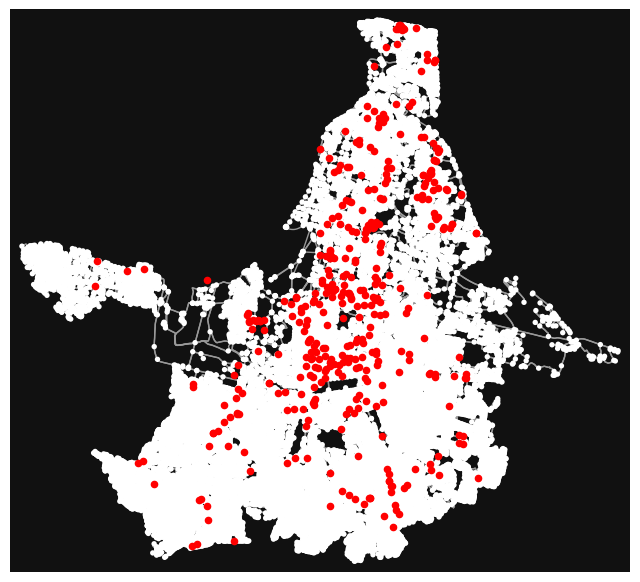

In [8]:
G = ox.graph_from_polygon(boundary_polygon, network_type='drive')
G = ox.truncate.largest_component(G, strongly=True)

tags = {'amenity': ['hospital', 'clinic'], 'healthcare': True}
facilities = ox.features_from_polygon(boundary_polygon, tags)
facilities = facilities[facilities.geometry.type.isin(['Point', 'Polygon'])].copy()
facilities['geometry'] = facilities.geometry.centroid

print(f"Roads: {len(G.nodes)} nodes, {len(G.edges)} edges")
print(f"Facilities found: {len(facilities)}")

fig, ax = ox.plot_graph(G, show=False, close=False)
facilities.plot(ax=ax, color='red', markersize=20)
plt.savefig("sanity_check.png")
plt.show()

In [9]:
print(facilities['name'].dropna().unique().tolist())

['Eden Hospital', 'Calcutta Medical College & Hospital', 'Vidyasagar State General Hospital', 'Sree Ramkrishna Pharmacy', 'Ballygunge Drugs Centre', 'Frank Ross', 'Sri Ramakrishna Pharmacy', 'Get Well', 'Chabi Medical', 'Peerless Hospital and B.K.Roy Research Center', 'Chittaranjan Shishu Hospital', 'Chittaranjan Seva Sadan', 'Chittaranjan National Cancer Institute Hospital', 'Centre Point Nursing Home', 'Aastha', 'Quadra Medical Services Pvt Ltd', 'Mayor Chect Clinick', 'Frank Ross Pharmacy', 'Das Pharmacy', 'Red Cross Society Medical Strore', 'Prima Orthopaedic Centre', 'Lokenath Medical Shop', 'ESI HOSPITAL, SEALDAH', 'Indonath Kundu', 'Chandi tala health center', 'Behala Balananda Brahmachari Hospital and Research Center', 'IRIS HOSPITAL', 'Paramount Clinic', 'Paramount Nursing Home', 'Dr Rafi Ahmed Dental College & Hospital', 'UNB building, NRS medical college', 'NRS OPD Building', 'Bekar Ward, NRS Medical College', 'NRS Medical college & Hospital', 'Dr Rafi Ahmed Dental College &

In [16]:
# Keep amenity=hospital, plus name-matched hospitals/nursing homes/medical colleges
keywords = ['hospital', 'medical college', 'nursing home', 'health centre', 'health center']

def is_healthcare_provider(row):
    if row.get('amenity') == 'hospital':
        return True
    name = str(row.get('name', '')).lower()
    return any(k in name for k in keywords)

facilities_filtered = facilities[facilities.apply(is_healthcare_provider, axis=1)].copy()
facilities_filtered = facilities_filtered.reset_index(drop=True)

print(f"Filtered facilities: {len(facilities_filtered)} (from {len(facilities)} total)")
print(facilities_filtered['name'].tolist())

Filtered facilities: 278 (from 401 total)
['Eden Hospital', 'Calcutta Medical College & Hospital', 'Vidyasagar State General Hospital', nan, 'Peerless Hospital and B.K.Roy Research Center', 'Chittaranjan Shishu Hospital', 'Chittaranjan Seva Sadan', 'Chittaranjan National Cancer Institute Hospital', 'Centre Point Nursing Home', 'Mayor Chect Clinick', 'Prima Orthopaedic Centre', 'ESI HOSPITAL, SEALDAH', 'Chandi tala health center', 'Behala Balananda Brahmachari Hospital and Research Center', 'IRIS HOSPITAL', 'Paramount Nursing Home', 'Dr Rafi Ahmed Dental College & Hospital', 'UNB building, NRS medical college', 'NRS OPD Building', 'Bekar Ward, NRS Medical College', 'NRS Medical college & Hospital', 'Dr Rafi Ahmed Dental College & Hospital, Old Campus', 'Obs & Gynaecology Building, NRS', nan, 'Micro Phaco Surgery Centre', 'Recovery Nursing Home Pvt Ltd', 'Red Plus Society Nursing Home', 'The May Fair Hospital', 'Rameswara Nursing Home Pvt Ltd', 'Ramkrishna Medical Complex Nursing Home', 

In [19]:
import subprocess
download_process = subprocess.Popen(
    ["wget", "-O", "ind_ppp_2020.tif",
     "https://data.worldpop.org/GIS/Population/Global_2000_2020/2020/IND/ind_ppp_2020.tif"]
)
print("Download started in background. Proceeding with other steps while it downloads.")

Download started in background. Proceeding with other steps while it downloads.


In [20]:
import networkx as nx

# Assign travel time to each road edge based on assumed speed
avg_speed_kmh = 25  # document this assumption in your report
for u, v, data in G.edges(data=True):
    length_km = data['length'] / 1000
    data['travel_time_min'] = (length_km / avg_speed_kmh) * 60

# Snap each filtered facility to nearest road network node
facilities_filtered['nearest_node'] = ox.distance.nearest_nodes(
    G, facilities_filtered.geometry.x, facilities_filtered.geometry.y
)

facility_nodes = facilities_filtered['nearest_node'].tolist()

# Compute travel time from every node in the network to its nearest facility
all_times = nx.multi_source_dijkstra_path_length(
    G, sources=set(facility_nodes), weight='travel_time_min'
)

print(f"Computed travel times for {len(all_times)} of {len(G.nodes)} nodes")
print(f"Min: {min(all_times.values()):.1f} min, Max: {max(all_times.values()):.1f} min")

Computed travel times for 39206 of 39206 nodes
Min: 0.0 min, Max: 20.8 min


In [21]:
import os
if os.path.exists("ind_ppp_2020.tif"):
    size_mb = os.path.getsize("ind_ppp_2020.tif") / (1024*1024)
    print(f"Downloaded so far: {size_mb:.1f} MB")
else:
    print("File not found yet")

Downloaded so far: 171.4 MB


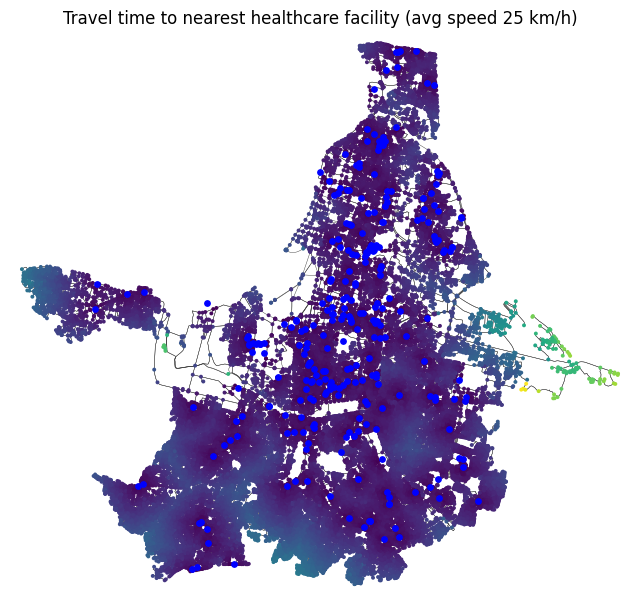

In [22]:
import matplotlib.pyplot as plt

node_colors = [all_times.get(node, float('nan')) for node in G.nodes()]

fig, ax = ox.plot_graph(
    G, node_color=node_colors, node_size=8, node_zorder=2,
    edge_linewidth=0.3, edge_color='#333333',
    show=False, close=False, bgcolor='white'
)
plt.set_cmap('RdYlGn_r')
facilities_filtered.plot(ax=ax, color='blue', markersize=15, zorder=3)
plt.title(f"Travel time to nearest healthcare facility (avg speed {avg_speed_kmh} km/h)")
plt.savefig("isochrone_map.png", dpi=150, bbox_inches='tight')
plt.show()

In [23]:
from shapely.geometry import box
import geopandas as gpd

minx, miny, maxx, maxy = kmc.total_bounds
cell_size = 0.005  # ~500m

grid_cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))
        y += cell_size
    x += cell_size

grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=kmc.crs)
grid = grid[grid.intersects(boundary_polygon)].reset_index(drop=True)
grid['centroid'] = grid.geometry.centroid

print(f"Grid cells created: {len(grid)}")

Grid cells created: 765


/tmp/ipykernel_903/1881572826.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid['centroid'] = grid.geometry.centroid


In [24]:
import os
if os.path.exists("ind_ppp_2020.tif"):
    size_mb = os.path.getsize("ind_ppp_2020.tif") / (1024*1024)
    print(f"Downloaded so far: {size_mb:.1f} MB")

Downloaded so far: 371.6 MB


In [25]:
# Assign each grid cell to its nearest facility using the same multi-source Dijkstra
lengths, paths = nx.multi_source_dijkstra(G, sources=set(facility_nodes), weight='travel_time_min')

node_to_facility_node = {}
for idx, row in facilities_filtered.iterrows():
    node_to_facility_node[row['nearest_node']] = idx

grid['nearest_node'] = ox.distance.nearest_nodes(G, grid['centroid'].x, grid['centroid'].y)
grid['travel_time_min'] = grid['nearest_node'].map(all_times).fillna(float('inf'))

grid['assigned_facility'] = grid['nearest_node'].apply(
    lambda n: node_to_facility_node.get(paths[n][0]) if n in paths and len(paths[n]) > 0 else None
)

print(grid[['travel_time_min', 'assigned_facility']].describe(include='all'))
print(f"Grid cells with valid facility assignment: {grid['assigned_facility'].notna().sum()} / {len(grid)}")

       travel_time_min  assigned_facility
count       765.000000         765.000000
mean          3.302241         142.669281
std           3.557924          79.913953
min           0.000000           0.000000
25%           1.214716          70.000000
50%           2.259530         148.000000
75%           3.893965         212.000000
max          20.283360         276.000000
Grid cells with valid facility assignment: 765 / 765


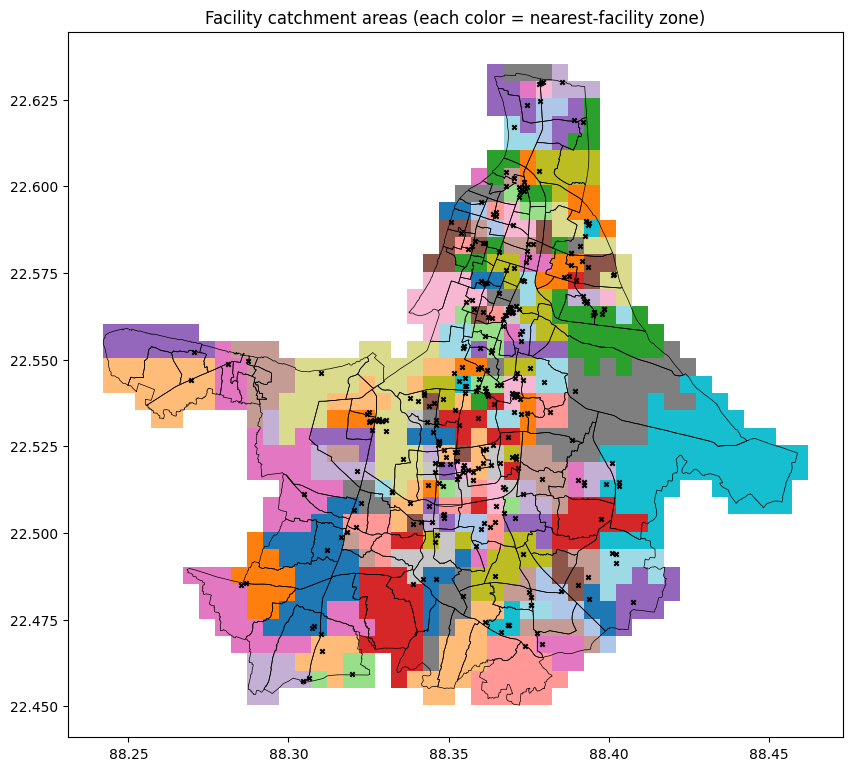

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
grid.plot(column='assigned_facility', ax=ax, cmap='tab20', legend=False, edgecolor='none')
facilities_filtered.plot(ax=ax, color='black', markersize=10, marker='x')
kmc.boundary.plot(ax=ax, color='black', linewidth=0.5)
plt.title("Facility catchment areas (each color = nearest-facility zone)")
plt.savefig("catchment_map.png", dpi=150, bbox_inches='tight')
plt.show()

In [27]:
import os
if os.path.exists("ind_ppp_2020.tif"):
    size_mb = os.path.getsize("ind_ppp_2020.tif") / (1024*1024)
    print(f"Downloaded so far: {size_mb:.1f} MB")

Downloaded so far: 482.5 MB


In [28]:
def assign_capacity(row):
    name = str(row.get('name', '')).lower()
    if 'medical college' in name or row.get('amenity') == 'hospital' and any(
        k in name for k in ['sskm', 'nrs', 'rg kar', 'medica', 'amri', 'fortis',
                             'apollo', 'peerless', 'woodlands', 'ruby', 'b.p. poddar']
    ):
        return 500  # major hospital / medical college
    elif row.get('amenity') == 'hospital':
        return 200  # general hospital
    elif 'nursing home' in name:
        return 80   # nursing home
    else:
        return 50   # smaller clinic/other

facilities_filtered['assumed_capacity'] = facilities_filtered.apply(assign_capacity, axis=1)

print(facilities_filtered['assumed_capacity'].value_counts())

assumed_capacity
200    170
80      65
500     40
50       3
Name: count, dtype: int64


In [29]:
import os
if os.path.exists("ind_ppp_2020.tif"):
    print(f"{os.path.getsize('ind_ppp_2020.tif')/(1024*1024):.1f} MB")

720.8 MB


In [30]:
# Temporary: rank grid cells by travel time alone, until population is ready
underserved_candidates_temp = grid.sort_values('travel_time_min', ascending=False).head(15)
print(underserved_candidates_temp[['travel_time_min', 'assigned_facility']])

     travel_time_min  assigned_facility
724        20.283360                251
731        18.594977                251
760        17.901900                251
759        17.901900                251
763        17.901900                251
761        17.748559                251
747        17.586188                251
764        17.286925                251
738        16.946604                251
737        16.931626                251
762        16.698914                251
754        16.580991                251
755        16.580991                251
744        16.526594                251
743        16.526594                251


In [31]:
def population_within_threshold(G, facility_nodes, grid, threshold=15, pop_col='population'):
    lengths = nx.multi_source_dijkstra_path_length(G, sources=set(facility_nodes), weight='travel_time_min')
    grid_copy = grid.copy()
    grid_copy['t'] = grid_copy['nearest_node'].map(lengths).fillna(float('inf'))
    if pop_col in grid_copy.columns:
        return grid_copy.loc[grid_copy['t'] <= threshold, pop_col].sum()
    else:
        return (grid_copy['t'] <= threshold).sum()

baseline_temp = population_within_threshold(G, facility_nodes, grid, threshold=15)
print(f"Baseline (cell count within 15min, temporary proxy): {baseline_temp}")

Baseline (cell count within 15min, temporary proxy): 738


In [32]:
import os
if os.path.exists("ind_ppp_2020.tif"):
    print(f"{os.path.getsize('ind_ppp_2020.tif')/(1024*1024):.1f} MB")

816.6 MB


In [33]:
import os
print(f"{os.path.getsize('ind_ppp_2020.tif')/(1024*1024):.1f} MB")

980.1 MB


In [34]:
import os
print(f"{os.path.getsize('ind_ppp_2020.tif')/(1024*1024):.1f} MB")

1236.2 MB


In [35]:
import os
print(f"{os.path.getsize('ind_ppp_2020.tif')/(1024*1024):.1f} MB")

1437.4 MB


In [36]:
import os
print(f"{os.path.getsize('ind_ppp_2020.tif')/(1024*1024):.1f} MB")

1758.7 MB


In [37]:
import os, time
time.sleep(10)  # give it a moment to finish flushing
size1 = os.path.getsize("ind_ppp_2020.tif")
time.sleep(5)
size2 = os.path.getsize("ind_ppp_2020.tif")
print(f"Size check 1: {size1/(1024*1024):.1f} MB")
print(f"Size check 2: {size2/(1024*1024):.1f} MB")
print("Download complete" if size1 == size2 else "Still downloading...")

Size check 1: 1758.7 MB
Size check 2: 1758.7 MB
Download complete


In [38]:
import rasterio
from rasterio.mask import mask
from rasterstats import zonal_stats

with rasterio.open("ind_ppp_2020.tif") as src:
    out_image, out_transform = mask(src, [boundary_polygon], crop=True)
    out_meta = src.meta.copy()

pop_array = out_image[0]
pop_array[pop_array < 0] = 0

out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

with rasterio.open("kmc_population.tif", "w", **out_meta) as dest:
    dest.write(out_image)

print(f"Total population in KMC (raw sum): {pop_array.sum():,.0f}")

stats = zonal_stats(grid, "kmc_population.tif", stats="sum", nodata=-99999)
grid['population'] = [s['sum'] if s['sum'] else 0 for s in stats]

print(f"Total population (gridded): {grid['population'].sum():,.0f}")
print(grid['population'].describe())

grid['assigned_facility_name'] = grid['assigned_facility'].map(facilities_filtered['name'])
demand_per_facility = grid.groupby('assigned_facility')['population'].sum()
facilities_filtered['demand'] = facilities_filtered.index.map(demand_per_facility).fillna(0)
facilities_filtered['load_ratio'] = facilities_filtered['demand'] / facilities_filtered['assumed_capacity']

print(facilities_filtered[['name', 'demand', 'assumed_capacity', 'load_ratio']].sort_values('load_ratio', ascending=False).head(15))

grid['travel_time_norm'] = grid['travel_time_min'] / grid['travel_time_min'].replace(float('inf'), None).max()
grid['pop_density_norm'] = grid['population'] / grid['population'].max()
grid['facility_load_norm'] = grid['assigned_facility'].map(facilities_filtered['load_ratio']).fillna(0)
grid['facility_load_norm'] = grid['facility_load_norm'] / grid['facility_load_norm'].max()

grid['underserved_score'] = (
    0.5 * grid['travel_time_norm'] +
    0.3 * grid['pop_density_norm'] +
    0.2 * grid['facility_load_norm']
)

underserved = grid[grid['underserved_score'] > grid['underserved_score'].quantile(0.8)]
print(f"\nTop underserved cells: {len(underserved)}")
print(underserved[['travel_time_min', 'population', 'underserved_score']].sort_values('underserved_score', ascending=False).head(10))

Total population in KMC (raw sum): 6,055,171
Total population (gridded): 6,055,171
count      765.000000
mean      7915.256016
std       8285.375294
min          0.000000
25%       3945.405273
50%       6771.798340
75%       9652.546875
max      67532.687500
Name: population, dtype: float64
                                            name         demand  \
31                        Sakuntala Nursing Home  331653.756348   
3                                            NaN  377014.077637   
96                     Sree Krishna Nursing Home  124388.852592   
10                      Prima Orthopaedic Centre  280218.634766   
114                             Des Nursing Home  110170.150391   
45                           Udayan Nursing Home   95999.955658   
173  Vivekananda Hospital and Research Institute  190913.656616   
66                   Vivekananda Eye Care Centre  154797.410690   
162                         Revival Nursing Home   55997.350586   
54                 Ekbalpur Nursing Ho

In [39]:
print(facilities_filtered.loc[3])

geometry            POINT (88.3121663 22.4951399)
amenity                                  hospital
healthcare                               hospital
name                                          NaN
name:en                                       NaN
                                ...              
alt_name:bn                                   NaN
nearest_node                          10091353264
assumed_capacity                              200
demand                              377014.077637
load_ratio                            1885.070388
Name: 3, Length: 78, dtype: object


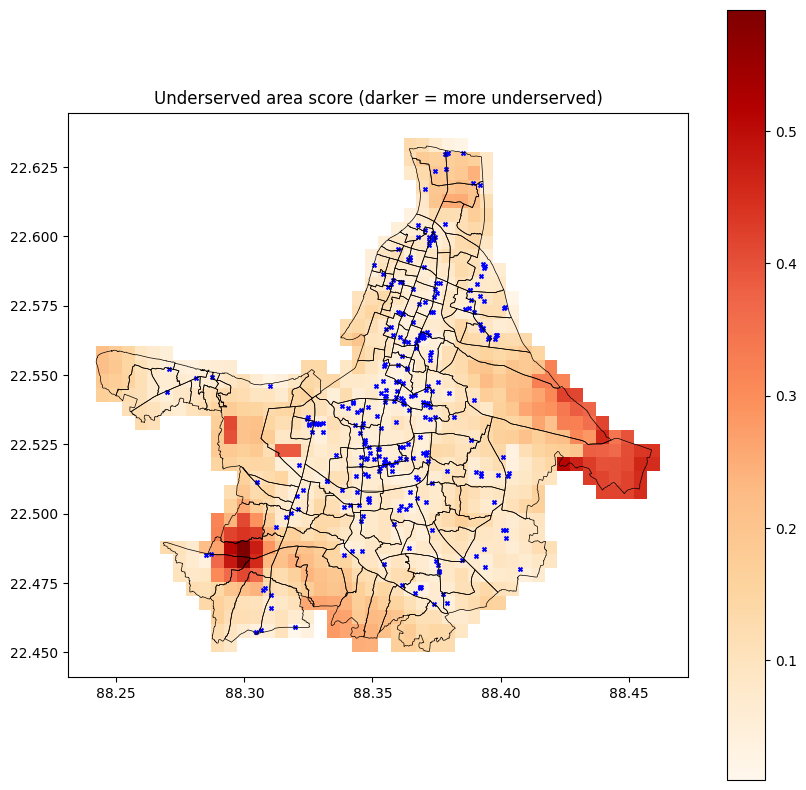

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
grid.plot(column='underserved_score', ax=ax, cmap='OrRd', legend=True, edgecolor='none')
facilities_filtered.plot(ax=ax, color='blue', markersize=8, marker='x')
kmc.boundary.plot(ax=ax, color='black', linewidth=0.5)
plt.title("Underserved area score (darker = more underserved)")
plt.savefig("underserved_map.png", dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Candidate sites = centroids of the highest-scoring underserved cells
candidates = underserved.sort_values('underserved_score', ascending=False).head(10).copy()
print(candidates[['travel_time_min', 'population', 'underserved_score']])

     travel_time_min    population  underserved_score
99          3.914283  66409.015625           0.591498
98          3.601584  67213.804688           0.587365
724        20.283360    324.236542           0.511774
80          2.535020  55596.218750           0.509465
79          2.713398  48474.445312           0.482225
118         3.361748  67532.687500           0.473811
731        18.594977      0.000000           0.468714
761        17.748559   3033.281738           0.461324
747        17.586188   3200.868652           0.458066
117         3.701762  66931.546875           0.456174


In [44]:
def population_within_threshold(facility_node_list, threshold=15):
    lengths = nx.multi_source_dijkstra_path_length(G, sources=set(facility_node_list), weight='travel_time_min')
    times = grid['nearest_node'].map(lengths).fillna(float('inf'))
    return grid.loc[times <= threshold, 'population'].sum()

baseline = population_within_threshold(facility_nodes)
print(f"Baseline population within 15 min: {baseline:,.0f}")

results = []
current_nodes = list(facility_nodes)
prev_covered = baseline

for i, (idx, row) in enumerate(candidates.iterrows(), start=1):
    if i > 3:
        break
    new_node = ox.distance.nearest_nodes(G, row['centroid'].x, row['centroid'].y)
    current_nodes.append(new_node)
    covered = population_within_threshold(current_nodes)
    marginal = covered - prev_covered
    results.append({
        'facility_num': i,
        'location_lon': row['centroid'].x,
        'location_lat': row['centroid'].y,
        'cumulative_covered': covered,
        'marginal_gain': marginal
    })
    prev_covered = covered

results_df = pd.DataFrame(results)
print(results_df)

Baseline population within 15 min: 6,029,267
   facility_num  location_lon  location_lat  cumulative_covered  marginal_gain
0             1     88.299643     22.487823        6.029267e+06       0.000000
1             2     88.299643     22.482823        6.029267e+06       0.000000
2             3     88.424643     22.517823        6.043157e+06   13889.530418


In [45]:
def max_travel_time(facility_node_list):
    lengths = nx.multi_source_dijkstra_path_length(G, sources=set(facility_node_list), weight='travel_time_min')
    times = grid['nearest_node'].map(lengths).fillna(float('inf'))
    return times.max()

baseline_worst = max_travel_time(facility_nodes)
print(f"Baseline worst-case travel time: {baseline_worst:.1f} min")

current_nodes = list(facility_nodes)
worst_case_results = []
prev_worst = baseline_worst

for i, (idx, row) in enumerate(candidates.iterrows(), start=1):
    if i > 3:
        break
    new_node = ox.distance.nearest_nodes(G, row['centroid'].x, row['centroid'].y)
    current_nodes.append(new_node)
    worst = max_travel_time(current_nodes)
    worst_case_results.append({
        'facility_num': i,
        'worst_case_travel_time': worst,
        'improvement': prev_worst - worst
    })
    prev_worst = worst

worst_df = pd.DataFrame(worst_case_results)
print(worst_df)

Baseline worst-case travel time: 20.3 min
   facility_num  worst_case_travel_time  improvement
0             1               20.283360     0.000000
1             2               20.283360     0.000000
2             3               16.657711     3.625649


In [46]:
# Re-pick candidates: top underserved cells, but spread across distinct locations
# (avoid picking two adjacent cells in the same pocket)
from shapely.geometry import Point

candidates_sorted = underserved.sort_values('underserved_score', ascending=False).copy()
selected = []
min_separation = 0.02  # ~2km in degrees, avoid picking neighbors

for idx, row in candidates_sorted.iterrows():
    too_close = any(row['centroid'].distance(s['centroid']) < min_separation for s in selected)
    if not too_close:
        selected.append(row)
    if len(selected) == 3:
        break

candidates_v2 = pd.DataFrame(selected)
print(candidates_v2[['travel_time_min', 'population', 'underserved_score']])

     travel_time_min    population  underserved_score
99          3.914283  66409.015625           0.591498
724        20.283360    324.236542           0.511774
761        17.748559   3033.281738           0.461324


In [47]:
current_nodes = list(facility_nodes)
prev_covered = baseline
results_v2 = []

for i, (idx, row) in enumerate(candidates_v2.iterrows(), start=1):
    if i > 3:
        break
    new_node = ox.distance.nearest_nodes(G, row['centroid'].x, row['centroid'].y)
    current_nodes.append(new_node)
    covered = population_within_threshold(current_nodes)
    marginal = covered - prev_covered
    results_v2.append({
        'facility_num': i,
        'location_lon': row['centroid'].x,
        'location_lat': row['centroid'].y,
        'cumulative_covered': covered,
        'marginal_gain': marginal
    })
    prev_covered = covered

results_v2_df = pd.DataFrame(results_v2)
print(results_v2_df)

   facility_num  location_lon  location_lat  cumulative_covered  marginal_gain
0             1     88.299643     22.487823        6.029267e+06       0.000000
1             2     88.424643     22.517823        6.043157e+06   13889.530418
2             3     88.454643     22.517823        6.048203e+06    5045.924767


In [48]:
current_nodes = list(facility_nodes)
prev_worst = baseline_worst
worst_v2 = []

for i, (idx, row) in enumerate(candidates_v2.iterrows(), start=1):
    if i > 3:
        break
    new_node = ox.distance.nearest_nodes(G, row['centroid'].x, row['centroid'].y)
    current_nodes.append(new_node)
    worst = max_travel_time(current_nodes)
    worst_v2.append({
        'facility_num': i,
        'worst_case_travel_time': worst,
        'improvement': prev_worst - worst
    })
    prev_worst = worst

worst_v2_df = pd.DataFrame(worst_v2)
print(worst_v2_df)

   facility_num  worst_case_travel_time  improvement
0             1               20.283360     0.000000
1             2               16.657711     3.625649
2             3               15.029503     1.628207


In [49]:
grid_export = grid.drop(columns=['centroid']).copy()
grid_export.to_file("grid_export.geojson", driver="GeoJSON")

facilities_export = facilities_filtered[['name', 'geometry', 'assumed_capacity', 'demand', 'load_ratio']].copy()
facilities_export.to_file("facilities_export.geojson", driver="GeoJSON")

from google.colab import files
files.download("grid_export.geojson")
files.download("facilities_export.geojson")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
import pandas as pd